# **Problem Statement: House Price Prediction using SVR**

## **Objective**

The goal of this project is to build a machine learning model using **Support Vector Regression (SVR)** to predict house prices based on various features of the house.

---

## **Dataset Description**

The dataset contains information about houses, including features such as:

* Area (size of the house)
* Number of bedrooms
* Number of bathrooms
* Number of stories
* Parking availability
* Other relevant attributes

The target variable is:

* **Price of the house**

---

## **Problem Definition**

Given the input features of a house, develop an SVR model that can accurately predict the **price** of the house.

---

## **Tasks**

1. Load and explore the dataset
2. Perform data preprocessing:

   * Handle missing values
   * Encode categorical variables (if any)
   * Scale the features
3. Split the dataset into training and testing sets
4. Train an SVR model using an appropriate kernel (e.g., RBF)
5. Evaluate the model using suitable regression metrics:
   * Mean Squared Error (MSE)
   * R² Score

---

## **Expected Outcome**

A trained SVR model capable of predicting house prices with reasonable accuracy, along with an analysis of its performance.

---

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv('./Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [51]:
df = df[['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']]
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,13300000,7420,4,2,3,2,yes,no,no,no,yes,yes,furnished
1,12250000,8960,4,4,4,3,yes,no,no,no,yes,no,furnished
2,12250000,9960,3,2,2,2,yes,no,yes,no,no,yes,semi-furnished
3,12215000,7500,4,2,2,3,yes,no,yes,no,yes,yes,furnished
4,11410000,7420,4,1,2,2,yes,yes,yes,no,yes,no,furnished


In [52]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0:1].values

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), slice(5,12))], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [55]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

sc_Y = StandardScaler()
y_train = sc_Y.fit_transform(y_train)
y_test = sc_Y.transform(y_test)

In [56]:
from sklearn.svm import SVR

regressor = SVR(kernel='rbf')
regressor.fit(X_train, y_train)

c:\Users\yeshw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [57]:
y_test_pred = regressor.predict(X_test)
y_train_pred = regressor.predict(X_train)

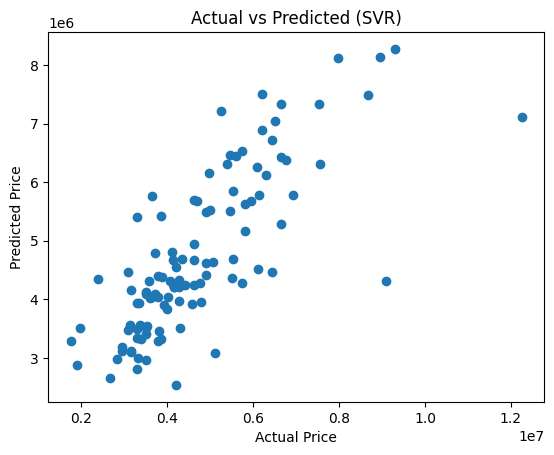

In [58]:
plt.scatter(sc_Y.inverse_transform(y_test.reshape(-1,1)), sc_Y.inverse_transform(y_test_pred.reshape(-1,1)))
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (SVR)")
plt.show()

In [59]:
from sklearn.metrics import r2_score, mean_squared_error

print(f"R^2 Score (Training Dataset) = {r2_score(y_train, y_train_pred)}")
print(f"R^2 Score (Test Dataset) = {r2_score(y_test, y_test_pred)}")

print(f"\nMSE Score (Training Dataset) = {mean_squared_error(y_train, y_train_pred)}")
print(f"MSE Score (Test Dataset) = {mean_squared_error(y_test, y_test_pred)}")

R^2 Score (Training Dataset) = 0.8068961431984648
R^2 Score (Test Dataset) = 0.6045259725327574

MSE Score (Training Dataset) = 0.19310385680153525
MSE Score (Test Dataset) = 0.3127081988318871


In [60]:
data = [[6850, 4, 3, 4, 5, "yes", "yes", "yes", "no", "no", "no", "unfurnished"]]

data = np.array(ct.transform(data))
data = sc_X.transform(data)

print(sc_Y.inverse_transform(regressor.predict(data).reshape(-1, 1)))

[[5839806.74921769]]
